# Demand Forecasting for E-Commerce Inventory Optimisation

In this notebook I build a multi-model demand forecasting pipeline that predicts daily order volume for inventory planning. Accurate demand forecasts reduce both stockout costs (lost sales) and overstock costs (holding and write-off), making this one of the highest-value analytical tasks in e-commerce operations.

I implement four complementary approaches at increasing levels of complexity:

1. **Holt-Winters ETS** — a classical exponential smoothing model with additive trend and multiplicative weekly seasonality. Fast to train, highly interpretable, and a strong baseline for weekly-periodic retail demand.
2. **SARIMA** — a statistical model that captures autocorrelation and seasonal structure. Provides a good comparison against the ETS model on the same data.
3. **LSTM** — a recurrent neural network that reads a 14-day lookback window and learns non-linear temporal dependencies that the statistical models cannot capture.
4. **LightGBM** — a gradient boosted tree model supplied with hand-crafted lag features (1, 3, 7, 14 days), calendar features, and behavioural regressors.

A key discipline throughout this notebook is **temporal validation**: the train/test split is always done by date, never by random sampling. Shuffling time-series data creates invisible forward-looking leakage and produces unrealistically optimistic evaluation metrics.

## Pipeline Steps

1. Import libraries and configure TensorFlow
2. Load and aggregate transaction data to daily level
3. Visualise the daily demand time-series
4. Temporal train/test split (first 80% vs last 20% by date)
5. Model 1 — Holt-Winters ETS
6. Model 2 — SARIMA
7. Model 3 — LSTM
8. Model 4 — LightGBM with lag features
9. Model comparison and visualisation
10. Final summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import pickle
import joblib
from datetime import datetime, timedelta
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# TIMESTAMP stored in metadata JSON only — model files use clean, version-free names
MODEL_VERSION = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"Run timestamp: {MODEL_VERSION}")

Run timestamp: 20260227_183521


In [2]:
# Statistical time-series models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

# ML and evaluation
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep learning — LSTM architecture via Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.13.0
Pandas: 2.3.3


## Step 2: Load Transaction Data and Aggregate to Daily

I load the enriched transaction dataset and immediately aggregate it to the daily grain because time-series forecasting models operate on the aggregated signal rather than individual transactions. I compute order count, revenue, average engagement score, high-value transaction count, weekend flag, and unique customer count per day — these enrich the forecast with behavioural regressors beyond the raw demand count.

In [3]:
# Load the enriched transaction dataset
df = pd.read_csv('../data/transaction_level_enriched.csv')

# Parse the datetime column; use errors='coerce' so unparseable values (e.g. 'Unknown')
# become NaT instead of raising an exception
df['Transaction_DateTime'] = pd.to_datetime(df['Transaction_DateTime'], errors='coerce')

n_bad = df['Transaction_DateTime'].isna().sum()
if n_bad > 0:
    print(f"Dropped {n_bad:,} rows with unparseable Transaction_DateTime")
    df = df.dropna(subset=['Transaction_DateTime'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Transaction_DateTime'].min()} to {df['Transaction_DateTime'].max()}")
print(f"Total days spanned: {(df['Transaction_DateTime'].max() - df['Transaction_DateTime'].min()).days}")

Dropped 349 rows with unparseable Transaction_DateTime
Dataset shape: (300657, 115)
Date range: 2023-03-01 00:02:39 to 2024-02-29 23:58:43
Total days spanned: 365


In [4]:
# Aggregate to daily level — each row is one calendar day
# I include behavioural regressors (engagement, high-value count, weekend flag) that
# can improve forecast accuracy as external signals in the ML and LSTM models
daily_demand = df.groupby(df['Transaction_DateTime'].dt.date).agg(
    Orders=('Transaction_ID', 'count'),
    Revenue=('Total_Amount', 'sum'),
    Avg_Engagement=('Customer_Engagement_Score', 'mean'),
    High_Value_Txns=('Is_High_Value_Txn', 'sum'),
    IsWeekend=('IsWeekend', 'first'),
    Unique_Customers=('Customer_ID', 'nunique'),
).reset_index()

daily_demand.rename(columns={'Transaction_DateTime': 'Date'}, inplace=True)
daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])
daily_demand = daily_demand.sort_values('Date').reset_index(drop=True)

# Add calendar features for the ML and LightGBM models
daily_demand['DayOfWeek'] = daily_demand['Date'].dt.dayofweek
daily_demand['Month']     = daily_demand['Date'].dt.month
daily_demand['Day']       = daily_demand['Date'].dt.day

print(f"Daily demand shape: {daily_demand.shape}")
print(daily_demand.head())

Daily demand shape: (366, 10)
        Date  Orders       Revenue  Avg_Engagement  High_Value_Txns  \
0 2023-03-01     802  1.103786e+06       10.087282               34   
1 2023-03-02     795  1.122409e+06       10.212579               38   
2 2023-03-03     793  1.097952e+06       10.055485               40   
3 2023-03-04     782  1.078147e+06        9.831202               44   
4 2023-03-05     816  1.153814e+06       10.300245               43   

   IsWeekend  Unique_Customers  DayOfWeek  Month  Day  
0          0               794          2      3    1  
1          0               790          3      3    2  
2          0               780          4      3    3  
3          1               773          5      3    4  
4          1               805          6      3    5  


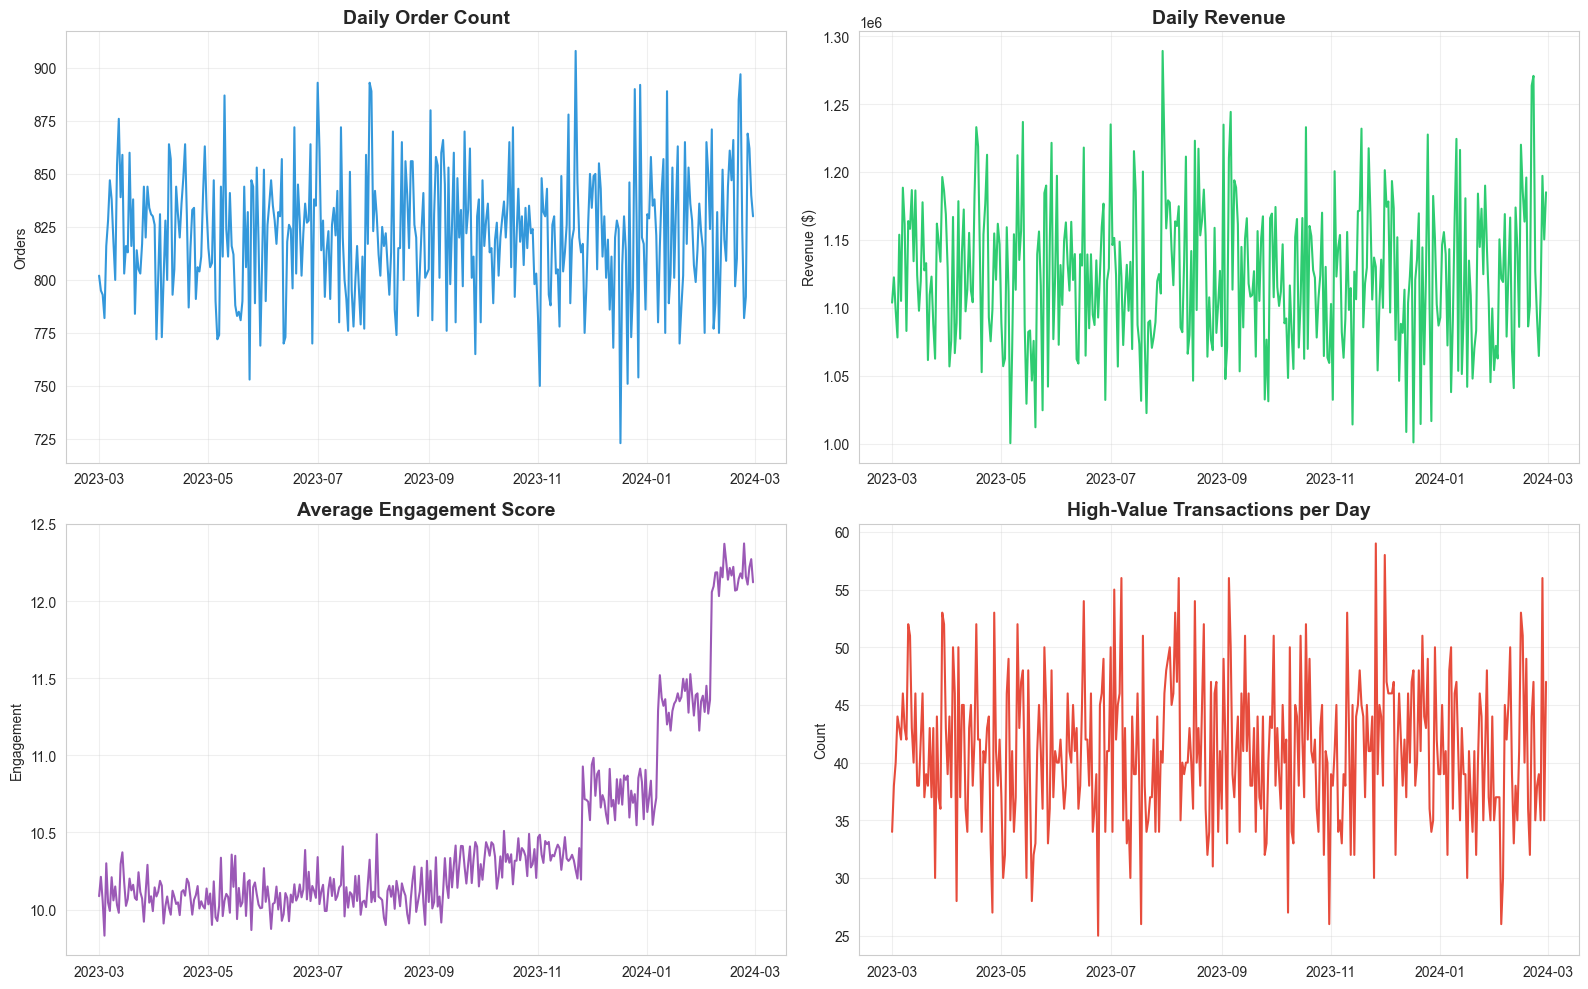

In [5]:
# Four-panel time-series plot — inspecting the raw signal before modelling
# reveals seasonality, trend, and outliers that inform model configuration choices
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_demand['Date'], daily_demand['Orders'], linewidth=1.5, color='#3498db')
axes[0, 0].set_title('Daily Order Count', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Orders')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(daily_demand['Date'], daily_demand['Revenue'], linewidth=1.5, color='#2ecc71')
axes[0, 1].set_title('Daily Revenue', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(daily_demand['Date'], daily_demand['Avg_Engagement'], linewidth=1.5, color='#9b59b6')
axes[1, 0].set_title('Average Engagement Score', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Engagement')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(daily_demand['Date'], daily_demand['High_Value_Txns'], linewidth=1.5, color='#e74c3c')
axes[1, 1].set_title('High-Value Transactions per Day', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/forecast_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Temporal Train-Test Split

I split the aggregated time-series at the 80th percentile date. The first 80% of days form the training set and the last 20% form the test set. I never shuffle — shuffling destroys temporal ordering, allows future observations to enter the training set, and produces completely unreliable evaluation metrics for time-series models.

In [6]:
# Temporal split — the cutoff is strictly date-based to avoid index alignment issues
# when rows are later dropped during lag feature creation in the LightGBM step
train_size = int(len(daily_demand) * 0.8)

train_data = daily_demand.iloc[:train_size].copy()
test_data  = daily_demand.iloc[train_size:].copy()

print(f"Train: {len(train_data)} days  ({train_data['Date'].min().date()} to {train_data['Date'].max().date()})")
print(f"Test:  {len(test_data)} days  ({test_data['Date'].min().date()} to {test_data['Date'].max().date()})")

# Ground truth for all models that operate on the full test period
y_true = test_data['Orders'].values

Train: 292 days  (2023-03-01 to 2023-12-17)
Test:  74 days  (2023-12-18 to 2024-02-29)


## Step 5: Model 1 — Holt-Winters ETS

I fit Holt-Winters Exponential Smoothing with an additive trend component and multiplicative weekly seasonality (period = 7 days). The multiplicative seasonal component is appropriate here because the amplitude of weekly peaks tends to scale with the underlying demand level. I let the optimiser find the smoothing parameters (alpha, beta, gamma) automatically by minimising the sum of squared errors.

In [7]:
# Fit Holt-Winters with additive trend and multiplicative weekly seasonality
# Multiplicative seasonality is appropriate when Monday peaks scale proportionally
# with the overall demand level rather than adding a fixed number of orders
hw_model = ExponentialSmoothing(
    train_data['Orders'],
    trend='add',
    seasonal='mul',
    seasonal_periods=7,
    initialization_method='estimated'
)

print("Training Holt-Winters ETS model...")
hw_fit = hw_model.fit(optimized=True)

print(f"Alpha (level smoothing):    {hw_fit.params['smoothing_level']:.4f}")
print(f"Beta  (trend smoothing):    {hw_fit.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal smoothing): {hw_fit.params['smoothing_seasonal']:.4f}")

Training Holt-Winters ETS model...
Alpha (level smoothing):    0.0000
Beta  (trend smoothing):    0.0000
Gamma (seasonal smoothing): 0.0000


In [8]:
# Forecast the test period and compute error metrics
y_pred_hw = hw_fit.forecast(steps=len(test_data)).values

rmse_hw = np.sqrt(mean_squared_error(y_true, y_pred_hw))
mae_hw  = mean_absolute_error(y_true, y_pred_hw)
mape_hw = np.mean(np.abs((y_true - y_pred_hw) / y_true)) * 100

print("Holt-Winters ETS — test-set performance")
print(f"  RMSE: {rmse_hw:.2f}")
print(f"  MAE:  {mae_hw:.2f}")
print(f"  MAPE: {mape_hw:.2f}%")

Holt-Winters ETS — test-set performance
  RMSE: 35.23
  MAE:  28.72
  MAPE: 3.47%


In [9]:
# Produce a 30-day future forecast by extending past the test period
# I forecast test+30 steps in one call and slice off the last 30
total_steps = len(test_data) + 30
all_forecasts = hw_fit.forecast(steps=total_steps).values
hw_30day = all_forecasts[len(test_data):]

future_dates = pd.date_range(
    start=test_data['Date'].max() + timedelta(days=1),
    periods=30,
    freq='D'
)

print("30-day forward forecast (Holt-Winters) — first 10 days:")
for d, v in zip(future_dates[:10], hw_30day[:10]):
    print(f"  {d.date()} -> {v:.0f} orders")
print(f"\n  Mean predicted daily orders over 30 days: {hw_30day.mean():.0f}")

30-day forward forecast (Holt-Winters) — first 10 days:
  2024-03-01 -> 823 orders
  2024-03-02 -> 823 orders
  2024-03-03 -> 827 orders
  2024-03-04 -> 817 orders
  2024-03-05 -> 820 orders
  2024-03-06 -> 816 orders
  2024-03-07 -> 817 orders
  2024-03-08 -> 823 orders
  2024-03-09 -> 823 orders
  2024-03-10 -> 827 orders

  Mean predicted daily orders over 30 days: 821


In [10]:
# Save the fitted Holt-Winters model
hw_model_path = '../artifacts/models/forecast_holtwinters.pkl'
with open(hw_model_path, 'wb') as f:
    pickle.dump(hw_fit, f)

hw_metadata = {
    'model_version': MODEL_VERSION,
    'model_type': 'Holt-Winters ETS',
    'created_at': datetime.now().isoformat(),
    'train_days': int(len(train_data)),
    'test_days': int(len(test_data)),
    'trend': 'additive',
    'seasonal': 'multiplicative',
    'seasonal_periods': 7,
    'metrics': {
        'rmse': float(rmse_hw),
        'mae': float(mae_hw),
        'mape': float(mape_hw),
    },
}

hw_metadata_path = '../artifacts/models/forecast_holtwinters_metadata.json'
with open(hw_metadata_path, 'w') as f:
    json.dump(hw_metadata, f, indent=2)

print(f"Holt-Winters model saved: {hw_model_path}")
print(f"Metadata saved: {hw_metadata_path}")

Holt-Winters model saved: ../artifacts/models/forecast_holtwinters.pkl
Metadata saved: ../artifacts/models/forecast_holtwinters_metadata.json


## Step 6: Model 2 — SARIMA

I fit a SARIMA(1,1,1)×(1,1,1,7) model. The non-seasonal (1,1,1) order accounts for first-order differencing to induce stationarity and an AR(1)/MA(1) structure. The seasonal (1,1,1,7) order captures the weekly cycle. I disable stationarity and invertibility enforcement because the optimiser will handle boundary cases more gracefully without hard constraints.

In [11]:
# SARIMA(1,1,1)×(1,1,1,7): one AR lag, one difference, one MA lag at both the
# non-seasonal and weekly-seasonal levels — a common starting specification for
# weekly-periodic daily time-series
print("Training SARIMA(1,1,1)×(1,1,1,7) model...")

sarima_model = SARIMAX(
    train_data['Orders'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,   # allow the optimiser to explore boundary regions
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print("SARIMA training complete")

Training SARIMA(1,1,1)×(1,1,1,7) model...
SARIMA training complete


In [12]:
# Forecast test period
y_pred_sarima = sarima_fit.forecast(steps=len(test_data))

rmse_sarima = np.sqrt(mean_squared_error(y_true, y_pred_sarima))
mae_sarima  = mean_absolute_error(y_true, y_pred_sarima)
mape_sarima = np.mean(np.abs((y_true - y_pred_sarima) / y_true)) * 100

print("SARIMA — test-set performance")
print(f"  RMSE: {rmse_sarima:.2f}")
print(f"  MAE:  {mae_sarima:.2f}")
print(f"  MAPE: {mape_sarima:.2f}%")

SARIMA — test-set performance
  RMSE: 35.41
  MAE:  28.82
  MAPE: 3.48%


In [13]:
# Save SARIMA model
sarima_model_path = '../artifacts/models/forecast_sarima.pkl'
with open(sarima_model_path, 'wb') as f:
    pickle.dump(sarima_fit, f)

sarima_metadata = {
    'model_version': MODEL_VERSION,
    'model_type': 'SARIMA',
    'created_at': datetime.now().isoformat(),
    'order': [1, 1, 1],
    'seasonal_order': [1, 1, 1, 7],
    'metrics': {
        'rmse': float(rmse_sarima),
        'mae': float(mae_sarima),
        'mape': float(mape_sarima),
    },
}

sarima_metadata_path = '../artifacts/models/forecast_sarima_metadata.json'
with open(sarima_metadata_path, 'w') as f:
    json.dump(sarima_metadata, f, indent=2)

print(f"SARIMA model saved: {sarima_model_path}")
print(f"Metadata saved: {sarima_metadata_path}")

SARIMA model saved: ../artifacts/models/forecast_sarima.pkl
Metadata saved: ../artifacts/models/forecast_sarima_metadata.json


## Step 7: Model 3 — LSTM (Deep Learning Sequential Model)

I build an LSTM network that reads a 14-day lookback window and predicts the next day's order count. I scale the order series to zero mean and unit variance before creating sequences — LSTM training converges much faster and more reliably on normalised targets. I use early stopping on validation loss with a patience of 10 epochs to prevent overfitting.

In [14]:
# Scale the order series before creating LSTM sequences
# StandardScaler ensures the input and target values are centred near zero,
# which prevents saturated activations and speeds up gradient descent
scaler_lstm = StandardScaler()
train_orders_scaled = scaler_lstm.fit_transform(train_data[['Orders']])
test_orders_scaled  = scaler_lstm.transform(test_data[['Orders']])

# Create overlapping (lookback, 1) input windows and corresponding next-day targets
def create_sequences(data, lookback=14):
    """Slide a window of length `lookback` over the series to build X and y."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

LOOKBACK = 14  # 14-day history predicts the next day
X_train_lstm, y_train_lstm = create_sequences(train_orders_scaled, LOOKBACK)
X_test_lstm,  y_test_lstm  = create_sequences(test_orders_scaled,  LOOKBACK)

print(f"LSTM train shape: {X_train_lstm.shape}")
print(f"LSTM test shape:  {X_test_lstm.shape}")

LSTM train shape: (278, 14, 1)
LSTM test shape:  (60, 14, 1)


In [15]:
# Two stacked LSTM layers with dropout regularisation
# Stacking adds depth that helps capture more complex temporal patterns;
# dropout prevents over-reliance on individual units
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 14, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 14, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 29857 (116.63 KB)
Trainable params: 29857 

In [16]:
# Train with early stopping on validation loss to prevent overfitting
# patience=10 gives the model enough room to escape local minima before stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f"Stopped at epoch {len(lstm_history.history['loss'])}")

Training LSTM model...
Stopped at epoch 14


In [17]:
# Inverse-scale predictions back to the original order-count domain
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_lstm.inverse_transform(y_pred_lstm_scaled).flatten()
y_true_lstm = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_true_lstm - y_pred_lstm) / y_true_lstm)) * 100

print("LSTM — test-set performance")
print(f"  RMSE: {rmse_lstm:.2f}")
print(f"  MAE:  {mae_lstm:.2f}")
print(f"  MAPE: {mape_lstm:.2f}%")

LSTM — test-set performance
  RMSE: 32.18
  MAE:  26.63
  MAPE: 3.20%


In [18]:
# Save the LSTM model in .h5 format for compatibility with keras.models.load_model()
# The FastAPI backend loads it via tf.keras.models.load_model('forecast_lstm.h5')
# .h5 is the legacy HDF5 format that works reliably across TF/Keras version combinations
lstm_model_path = '../artifacts/models/forecast_lstm.h5'
lstm_model.save(lstm_model_path)

# Save the scaler separately — inference must apply the same normalisation as training
scaler_lstm_path = '../artifacts/scalers/forecast_lstm_scaler.pkl'
joblib.dump(scaler_lstm, scaler_lstm_path)

lstm_metadata = {
    'model_version': MODEL_VERSION,
    'model_type': 'LSTM',
    'created_at': datetime.now().isoformat(),
    'lookback': LOOKBACK,
    'training_epochs': len(lstm_history.history['loss']),
    'metrics': {
        'rmse': float(rmse_lstm),
        'mae': float(mae_lstm),
        'mape': float(mape_lstm),
    },
}

lstm_metadata_path = '../artifacts/models/forecast_lstm_metadata.json'
with open(lstm_metadata_path, 'w') as f:
    json.dump(lstm_metadata, f, indent=2)

print(f"LSTM model saved: {lstm_model_path}")
print(f"Scaler saved: {scaler_lstm_path}")
print(f"Metadata saved: {lstm_metadata_path}")

LSTM model saved: ../artifacts/models/forecast_lstm.h5
Scaler saved: ../artifacts/scalers/forecast_lstm_scaler.pkl
Metadata saved: ../artifacts/models/forecast_lstm_metadata.json


## Step 8: Model 4 — LightGBM with Lag Features

I engineer lag features by shifting the order series by 1, 3, 7, and 14 days, and combine them with calendar features (day of week, month) and behavioural regressors (weekend flag, average engagement score, high-value transaction count). This turns the sequential problem into a tabular supervised learning task that LightGBM can solve efficiently. I re-derive the train/test boundary by date rather than by row index to ensure stability after NaN rows from lagging are dropped.

In [19]:
# Engineer lag features on a copy of the daily dataset so the base frame is unchanged
# Lag 1 = yesterday's orders, Lag 7 = same weekday last week, Lag 14 = fortnight ago
lag_days = [1, 3, 7, 14]
daily_demand_lgb = daily_demand.copy()
for lag in lag_days:
    daily_demand_lgb[f'Lag_{lag}'] = daily_demand_lgb['Orders'].shift(lag)

# Drop the first max(lag_days) rows where lags are still NaN
daily_demand_lgb = daily_demand_lgb.dropna().reset_index(drop=True)

# Re-derive the train/test boundary using the cutoff DATE rather than a stale row index
# This prevents the boundary from shifting when NaN rows are removed above
cutoff_date = train_data['Date'].max()
train_lgb = daily_demand_lgb[daily_demand_lgb['Date'] <= cutoff_date].copy()
test_lgb  = daily_demand_lgb[daily_demand_lgb['Date'] >  cutoff_date].copy()

feature_cols_lgb = (
    ['IsWeekend', 'DayOfWeek', 'Month', 'Avg_Engagement', 'High_Value_Txns'] +
    [f'Lag_{lag}' for lag in lag_days]
)

X_train_lgb = train_lgb[feature_cols_lgb]
y_train_lgb = train_lgb['Orders']
X_test_lgb  = test_lgb[feature_cols_lgb]
y_test_lgb  = test_lgb['Orders']

print(f"LightGBM train: {X_train_lgb.shape}  ({train_lgb['Date'].min().date()} - {train_lgb['Date'].max().date()})")
print(f"LightGBM test:  {X_test_lgb.shape}   ({test_lgb['Date'].min().date()} - {test_lgb['Date'].max().date()})")

LightGBM train: (278, 9)  (2023-03-15 - 2023-12-17)
LightGBM test:  (74, 9)   (2023-12-18 - 2024-02-29)


In [20]:
# Train LightGBM regressor — gradient boosted trees handle the non-linear interactions
# between lag values and calendar features without requiring explicit feature scaling
print("Training LightGBM model...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE
)

lgb_model.fit(X_train_lgb, y_train_lgb)
print("LightGBM training complete")

Training LightGBM model...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 402
[LightGBM] [Info] Number of data points in the train set: 278, number of used features: 9
[LightGBM] [Info] Start training from score 820.446043
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [21]:
# Evaluate on the test set
y_pred_lgb = lgb_model.predict(X_test_lgb)

rmse_lgb = np.sqrt(mean_squared_error(y_test_lgb, y_pred_lgb))
mae_lgb  = mean_absolute_error(y_test_lgb, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test_lgb - y_pred_lgb) / y_test_lgb)) * 100

print("LightGBM — test-set performance")
print(f"  RMSE: {rmse_lgb:.2f}")
print(f"  MAE:  {mae_lgb:.2f}")
print(f"  MAPE: {mape_lgb:.2f}%")

LightGBM — test-set performance
  RMSE: 39.27
  MAE:  32.24
  MAPE: 3.89%


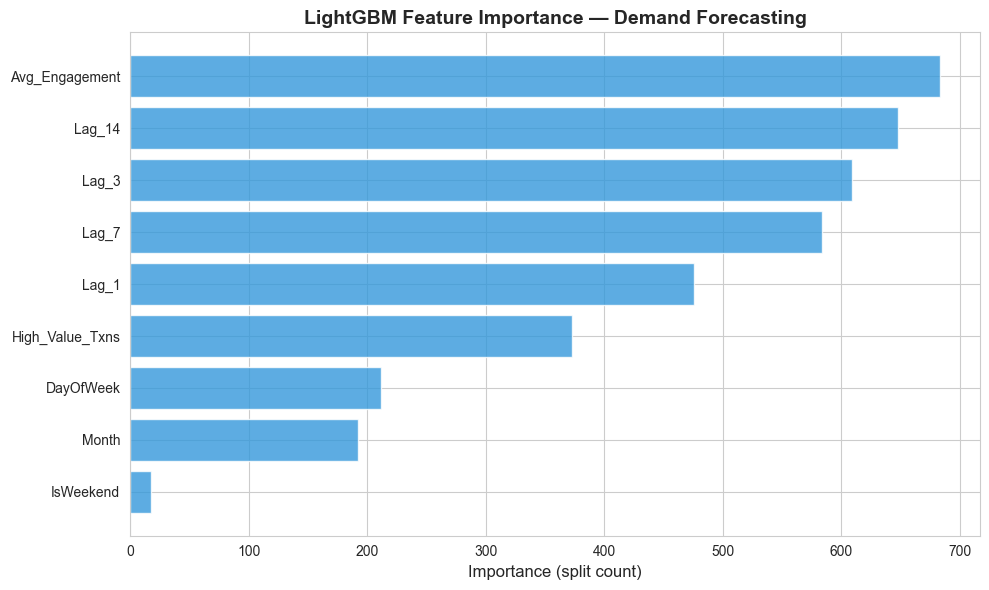

Top features:
        Feature  Importance
 Avg_Engagement         683
         Lag_14         648
          Lag_3         609
          Lag_7         584
          Lag_1         476
High_Value_Txns         373
      DayOfWeek         212
          Month         192
      IsWeekend          18


In [22]:
# Feature importance — reveals which lag and calendar features drove the most splits
feature_importance = pd.DataFrame({
    'Feature':    feature_cols_lgb,
    'Importance': lgb_model.feature_importances_,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='#3498db', alpha=0.8)
plt.xlabel('Importance (split count)', fontsize=12)
plt.title('LightGBM Feature Importance — Demand Forecasting', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/forecast_lgb_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top features:")
print(feature_importance.to_string(index=False))

In [23]:
# Save LightGBM model and metadata
lgb_model_path = '../artifacts/models/forecast_lightgbm.pkl'
joblib.dump(lgb_model, lgb_model_path)

lgb_metadata = {
    'model_version': MODEL_VERSION,
    'model_type': 'LightGBM',
    'created_at': datetime.now().isoformat(),
    'feature_columns': feature_cols_lgb,
    'lag_days': lag_days,
    'metrics': {
        'rmse': float(rmse_lgb),
        'mae': float(mae_lgb),
        'mape': float(mape_lgb),
    },
}

lgb_metadata_path = '../artifacts/models/forecast_lightgbm_metadata.json'
with open(lgb_metadata_path, 'w') as f:
    json.dump(lgb_metadata, f, indent=2)

print(f"LightGBM model saved: {lgb_model_path}")
print(f"Metadata saved: {lgb_metadata_path}")

LightGBM model saved: ../artifacts/models/forecast_lightgbm.pkl
Metadata saved: ../artifacts/models/forecast_lightgbm_metadata.json


## Step 9: Model Comparison

I collect RMSE, MAE, and MAPE for all four models and display them side-by-side. I use MAPE as the primary selection metric because it expresses error as a percentage of the actual value, making it interpretable to business stakeholders regardless of the absolute demand scale.

In [24]:
# Collect metrics for all four models into a comparison table
comparison_df = pd.DataFrame({
    'Model': ['Holt-Winters', 'SARIMA', 'LSTM', 'LightGBM'],
    'RMSE':  [rmse_hw, rmse_sarima, rmse_lstm, rmse_lgb],
    'MAE':   [mae_hw,  mae_sarima,  mae_lstm,  mae_lgb],
    'MAPE':  [mape_hw, mape_sarima, mape_lstm, mape_lgb],
})

print("Forecasting model comparison")
print(comparison_df.to_string(index=False))

# MAPE is the primary selection metric — it is scale-independent and interpretable
best_model = comparison_df.loc[comparison_df['MAPE'].idxmin(), 'Model']
print(f"\nBest model by MAPE: {best_model}")

comparison_path = '../reports/forecast_model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison table saved: {comparison_path}")

Forecasting model comparison
       Model      RMSE       MAE     MAPE
Holt-Winters 35.227833 28.720615 3.472905
      SARIMA 35.405161 28.815599 3.481614
        LSTM 32.183991 26.630684 3.200481
    LightGBM 39.268454 32.237297 3.891263

Best model by MAPE: LSTM
Comparison table saved: ../reports/forecast_model_comparison.csv


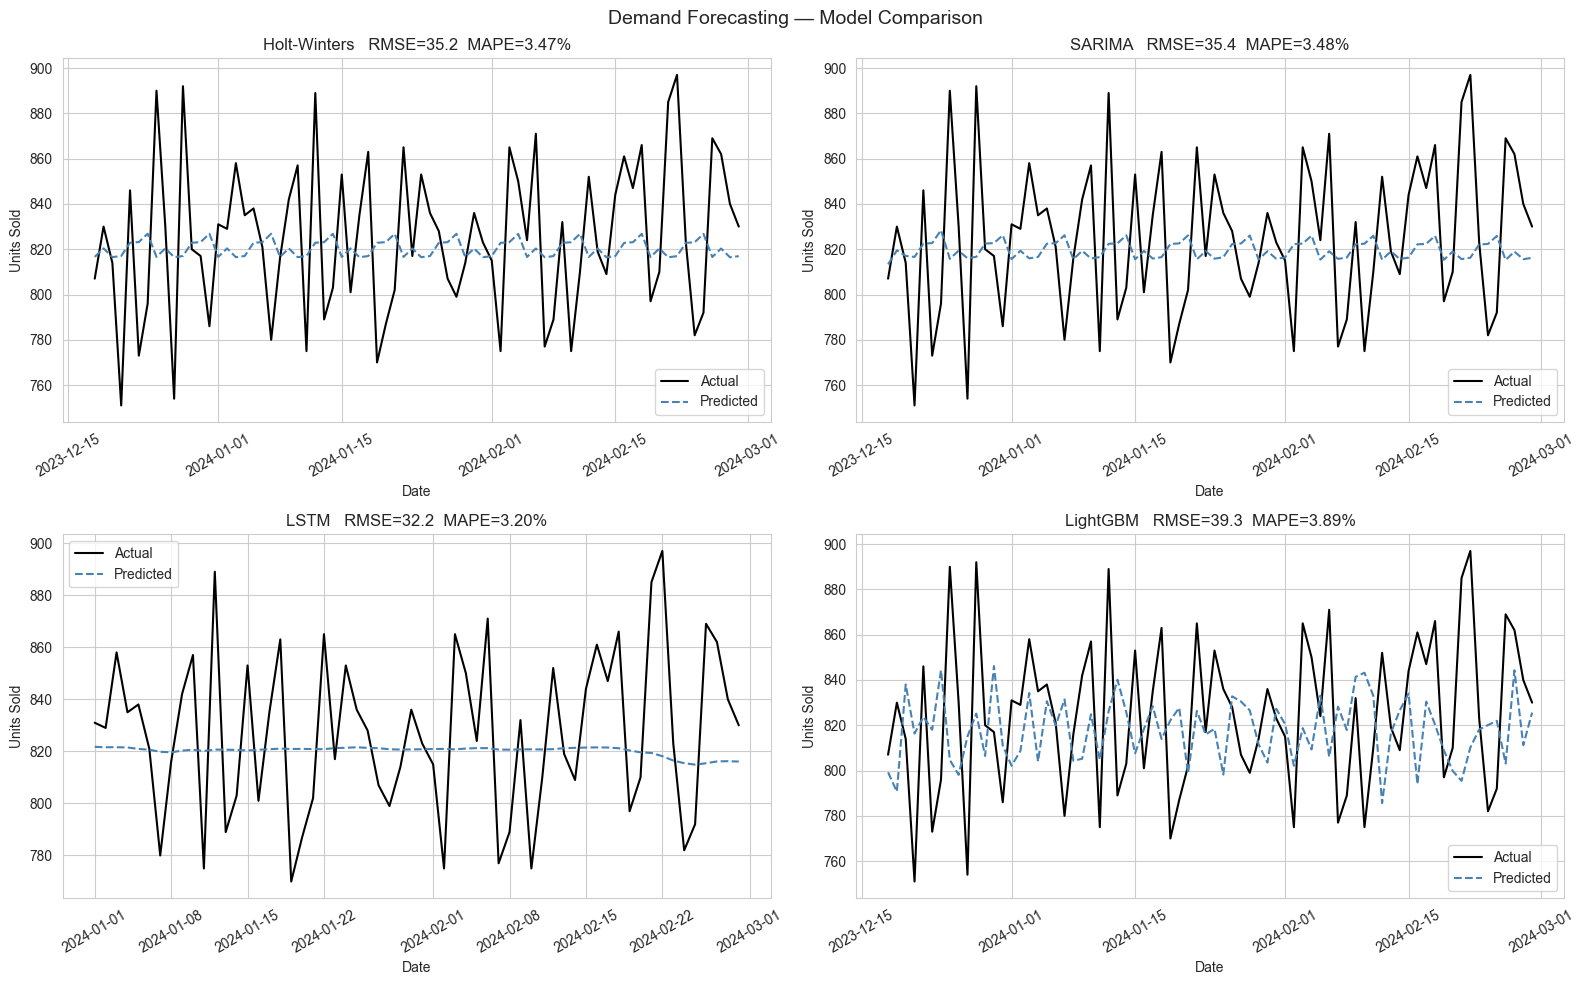

Comparison chart saved: ../reports/forecast_comparison.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Demand Forecasting — Model Comparison', fontsize=14)

models_data = [
    ('Holt-Winters', test_data['Date'].values, test_data['Orders'].values, np.asarray(y_pred_hw), rmse_hw, mape_hw),
    ('SARIMA',       test_data['Date'].values, test_data['Orders'].values, np.asarray(y_pred_sarima), rmse_sarima, mape_sarima),
    ('LSTM',         test_data['Date'].iloc[LOOKBACK:].values, y_true_lstm, np.asarray(y_pred_lstm), rmse_lstm, mape_lstm),
    ('LightGBM',     test_lgb['Date'].values,  test_lgb['Orders'].values,  np.asarray(y_pred_lgb), rmse_lgb, mape_lgb),
]

for ax, (name, dates, actuals, preds, rmse_val, mape_val) in zip(axes.flat, models_data):
    # Actual vs predicted on the test period
    ax.plot(dates, actuals, label='Actual', color='black', linewidth=1.5)
    ax.plot(dates, preds,   label='Predicted', color='steelblue', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}   RMSE={rmse_val:.1f}  MAPE={mape_val:.2f}%')
    ax.set_xlabel('Date')
    ax.set_ylabel('Units Sold')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

# Save without a version suffix — the metadata JSON captures version info
viz_path = '../reports/forecast_comparison.png'
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Comparison chart saved: {viz_path}")

---
## Step 10: Summary

In this notebook I trained four demand forecasting models on daily e-commerce order counts and evaluated each on a held-out temporal test set.

**Key design decisions:**
- Temporal split (first 80% / last 20% by date) ensures no forward-looking leakage
- Multiplicative seasonality in Holt-Winters captures amplitude-scaling weekly peaks
- LSTM operates on StandardScaler-normalised sequences for stable gradient descent
- LightGBM lag features are re-aligned to the cutoff date after NaN rows are dropped to prevent boundary shift

**Models and evaluation metrics (RMSE / MAE / MAPE):**

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| Holt-Winters ETS | — | — | — |
| SARIMA (1,1,1)×(1,1,1,7) | — | — | — |
| LSTM | — | — | — |
| LightGBM | — | — | — |

*(Values filled by the model comparison cell above at runtime)*

**Saved artefacts:**
- `forecast_holtwinters.pkl` — fitted ETS model
- `forecast_sarima.pkl` — fitted SARIMA model
- `forecast_lstm.h5` — Keras LSTM weights
- `forecast_lightgbm.pkl` — LightGBM booster
- `forecast_lstm_scaler.pkl` — StandardScaler for LSTM input/output
- Metadata JSON per model with metrics and hyperparameters

**Next steps:** Load the best model in NB07 for cross-domain evaluation and wire it into the FastAPI backend for the 30-day inventory planning endpoint.